In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("data\pa_transactor_annotaded_clean.csv")
df.head()

,index,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,0,3008,b60b4b0c-5067-4c44-826b-aac5a22d2609,franklin county reagan coalition,PA,Committee,NaN,7172670032
1,1,3009,c7461f6f-6118-48eb-a499-fc97d108f66f,nextgen climate action committee,PA,Committee,NaN,NaN
2,2,3010,14ae9bb5-57dc-422b-b517-8eaaf011cec8,zarwin baum good government pac,PA,Committee,NaN,2155692800
3,3,3011,7ab4636b-3513-4143-9c17-94115c991a75,mid-atlantic laborers' political league,PA,Committee,NaN,7038604194
4,4,3012,a445eb91-c855-410d-a046-0a942159d496,toll bros inc pac,PA,Committee,NaN,2159388000


In [45]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['full_name'])

In [46]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Committee':
        return 1
    else:
        return 0
y = np.vectorize(convert_bool)(df['transactor_type'])

In [47]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [48]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [49]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 95.14218009478674
Recall: 98.1294964028777
Precision: 96.05633802816902
f1_score: 97.08185053380784


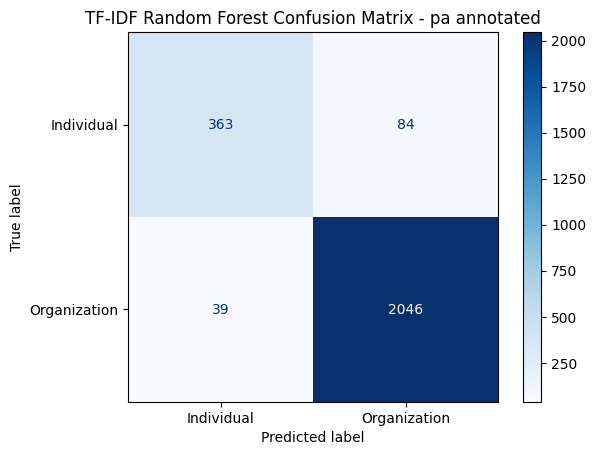

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
#Confusion matrix
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - pa annotated")
plt.show()

In [57]:
misclassified = np.where(y_val != predicted_y)[0]

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
  inverse_names_clean.append( " ".join(list(inverse_names[i]) ))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
    ctr+=1
    if(ctr >10):
      break
    print(f"ctr: {ctr}")
    print(f"Index: {i}")
    print(f"Full Name: {inverse_names_clean[ctr]}")
    print(f"True Label: {y_val[i]}, Predicted: {predicted_y[i]}")
    print("---")

Number of misclassified samples: 123
ctr: 0
Index: 25
Full Name: marsh laban
True Label: 0, Predicted: 1
---
ctr: 1
Index: 38
Full Name: ellen ceisler
True Label: 0, Predicted: 1
---
ctr: 2
Index: 40
Full Name: follweiler archie
True Label: 0, Predicted: 1
---
ctr: 3
Index: 59
Full Name: theresa brunson
True Label: 0, Predicted: 1
---
ctr: 4
Index: 67
Full Name: ida chen
True Label: 0, Predicted: 1
---
ctr: 5
Index: 132
Full Name: ellen ceisler
True Label: 0, Predicted: 1
---
ctr: 6
Index: 176
Full Name: schroeder meghan
True Label: 0, Predicted: 1
---
ctr: 7
Index: 208
Full Name: hyams carrie
True Label: 0, Predicted: 1
---
ctr: 8
Index: 230
Full Name: morgan cephas
True Label: 0, Predicted: 1
---
ctr: 9
Index: 231
Full Name: pradhan rajeev
True Label: 0, Predicted: 1
---
ctr: 10
Index: 235
Full Name: vedder clyde
True Label: 0, Predicted: 1
---
